In [17]:
from mtpy import MT, MTData
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np

In [14]:
edi_path = Path(r"c:\Users\jpeacock\OneDrive - DOI\EDI_FILES\latest_files")
edi_df = pd.read_csv(edi_path / "edi_file_summary_2026_03_23.csv")

In [7]:
bounding_box = {"lat": [37.165, 38.9], "lon": [-119.04, -117.05]}
clayton_df = edi_df.loc[
    (edi_df.latitude >= min(bounding_box["lat"]))
    & (edi_df.latitude <= max(bounding_box["lat"]))
    & (edi_df.longitude >= min(bounding_box["lon"]))
    & (edi_df.longitude <= max(bounding_box["lon"]))
]

In [8]:
utm_epsg = 32611

In [9]:
clayton_gdf = gpd.GeoDataFrame(
    clayton_df,
    geometry=gpd.points_from_xy(clayton_df.longitude, clayton_df.latitude),
    crs="EPSG:4326",
)

<Axes: >

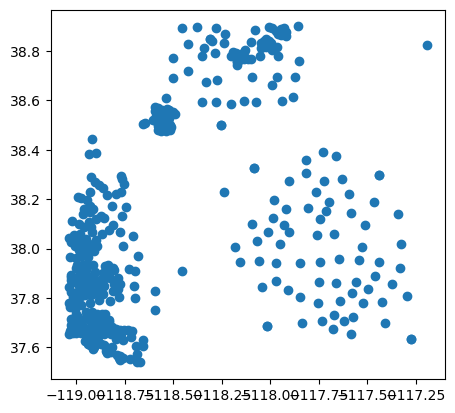

In [10]:
clayton_gdf.plot()

In [24]:
utm_gdf = clayton_gdf.to_crs(epsg=utm_epsg)
utm_gdf["mt_obj"] = None
for row in utm_gdf.itertuples():
    mt_obj = MT()
    mt_obj.read(edi_path / row.filename)
    utm_gdf.at[row.Index, "mt_obj"] = mt_obj


26:03:25T11:19:26 | WARNING | line:645 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.142127416470683e-18 for period 10000.0. Results may be inaccurate
26:03:25T11:19:26 | WARNING | line:645 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 7.558158005689144e-19 for period 8800.0. Results may be inaccurate
26:03:25T11:19:26 | WARNING | line:645 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.777384335720568e-19 for period 7200.0. Results may be inaccurate
26:03:25T11:19:26 | WARNING | line:645 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 1.2822091332431065e-19 for period 6000.0. Results may be inaccurate
26:03:25T11:19:26 | WARNING | line:645 |mt_metadata.transfer_functions.io.edi.edi | _read_spectra | spectral matrix determinant is too small 4.144059483896343e-20 for

In [78]:
dx = 2000

rows = []
for xx in np.arange(utm_gdf.geometry.x.min(), utm_gdf.geometry.x.max(), dx):
    for yy in np.arange(utm_gdf.geometry.y.min(), utm_gdf.geometry.y.max(), dx):
        box_gdf = utm_gdf.cx[xx : xx + dx, yy : yy + dx]
        if len(box_gdf) > 1:
            box_gdf["tf_quality"] = box_gdf.apply(
                lambda row: row.mt_obj.estimate_tf_quality(), axis=1
            )
            rows.append(box_gdf[box_gdf["tf_quality"] == box_gdf["tf_quality"].max()])
        elif len(box_gdf) == 1:
            rows.append(box_gdf)
        else:
            continue

downsampled_gdf = gpd.GeoDataFrame(pd.concat(rows), crs=utm_gdf.crs)


26:03:25T12:30:33 | WARNING | line:263 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Zxx: Need more x points.
26:03:25T12:30:33 | WARNING | line:339 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Tx: Expect t to be a 1D strictly increasing sequence.
26:03:25T12:30:33 | WARNING | line:339 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Ty: Expect t to be a 1D strictly increasing sequence.
26:03:25T12:30:33 | WARNING | line:339 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Tx: Expect t to be a 1D strictly increasing sequence.
26:03:25T12:30:33 | WARNING | line:339 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Ty: Expect t to be a 1D strictly increasing sequence.
26:03:25T12:30:33 | WARNING | line:263 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Zxx: Expect x to be a 1D non-decreasing sequence.
26:03:25T12:30:33 | WARNING | line:263 |mtpy.utils.estimate_tf_quality_factor | compute_statistics | Zx

<Axes: >

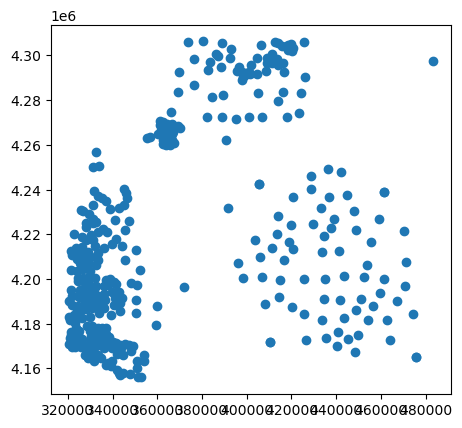

In [80]:
downsampled_gdf.plot()

In [61]:
def average_mt_objs(mt_objs, n_periods=48, survey="mina", count=1):

    # 1) Build interpolation grid
    period_list = np.concatenate([mt_obj.period for mt_obj in mt_objs])
    unique_periods = np.unique(np.array(period_list))
    interp_periods = np.logspace(np.log10(unique_periods.min()),
                                 np.log10(unique_periods.max()), n_periods)

    # 2) Interpolate onto common periods
    m_list_interp = [m.interpolate(interp_periods, bounds_error=False) for m in mt_objs]

    # 3) Stack data; enforce dtypes
    z_list = [m.impedance.data for m in m_list_interp if m.has_impedance()]
    zerr_list = [m.impedance_error.data for m in m_list_interp if m.has_impedance()]
    t_list = [m.tipper.data for m in m_list_interp if m.has_tipper()]
    terr_list = [m.tipper_error.data for m in m_list_interp if m.has_tipper()]

    if len(z_list) == 0 and len(t_list) == 0:
        raise ValueError("No impedance or tipper data found in provided MT objects.")

    # Force to expected dtypes
    if len(z_list):
        avg_z = np.asarray(z_list, dtype=np.complex128)
        avg_z_err = np.asarray(zerr_list, dtype=np.float64)
    else:
        avg_z = None
        avg_z_err = None

    if len(t_list):
        avg_t = np.asarray(t_list, dtype=np.complex128)
        avg_t_err = np.asarray(terr_list, dtype=np.float64)
    else:
        avg_t = None
        avg_t_err = None

    # 4) Replace sentinel zeros with NaNs of matching dtype
    if avg_z is not None:
        avg_z[avg_z == 0] = np.nan + 1j*np.nan
    if avg_z_err is not None:
        avg_z_err[avg_z_err == 0] = np.nan

    if avg_t is not None:
        avg_t[avg_t == 0] = np.nan + 1j*np.nan
    if avg_t_err is not None:
        avg_t_err[avg_t_err == 0] = np.nan

    # 5) Median across stations (nan-aware)
    if avg_z is not None:
        avg_z = np.nanmedian(avg_z, axis=0)
        avg_z_err = np.nanmedian(avg_z_err, axis=0)
    if avg_t is not None:
        avg_t = np.nanmedian(avg_t, axis=0)
        avg_t_err = np.nanmedian(avg_t_err, axis=0)

    # 6) Build averaged MT object
    mt_avg = MT()
    mt_avg.period = interp_periods

    # NOTE: Depending on mtpy version, assigning arrays directly to
    # mt_avg.impedance / tipper may require using the proper object wrappers.
    # If your MT object expects an Impedance/Tipper object, use its setter APIs.
    if avg_z is not None:
        mt_avg.impedance = avg_z
        mt_avg.impedance_error = avg_z_err
    if avg_t is not None:
        mt_avg.tipper = avg_t
        mt_avg.tipper_error = avg_t_err

    mt_avg.latitude = float(np.mean([m.latitude for m in mt_objs]))
    mt_avg.longitude = float(np.mean([m.longitude for m in mt_objs]))
    mt_avg.elevation = float(np.mean([m.elevation for m in mt_objs]))
    mt_avg.station = f"{survey}_avg{count:03d}"

    # Avoid double assignment (you had it twice)
    mt_avg.survey_metadata.summary = (
        "averaged_stations: " + ", ".join([m.station for m in mt_objs])
    )
    mt_avg.survey_metadata.id = "averaged"

    return mt_avg


In [81]:
import numpy as np
import pandas as pd
import geopandas as gpd

dx = 2000  # grid cell size in meters

rows = []
count = 1

xmin, ymin, xmax, ymax = utm_gdf.total_bounds

# Precompute grid indices for each row to avoid nested loops and .cx slicing
ix = ((utm_gdf.geometry.x - xmin) // dx).astype(int)
iy = ((utm_gdf.geometry.y - ymin) // dx).astype(int)
gdf_grid = utm_gdf.assign(ix=ix, iy=iy)

for (cell_x, cell_y), group in gdf_grid.groupby(["ix", "iy"]):
    # group contains all sites in this 2km x 2km cell
    if group.shape[0] >= 2:
        # ---------- average branch ----------
        mt_obj_avg = average_mt_objs(group["mt_obj"].tolist(), survey="mina", count=count)
        # If your average_mt_objs function returns a tuple, unpack it here:
        # mt_obj_avg, = average_mt_objs(...)

        mt_avg_filename = f"{mt_obj_avg.station}_mina_averaged.edi"
        mt_obj_avg.write(edi_path / mt_avg_filename)
        count += 1

        # Start from the first row and make a dict so schema stays consistent
        base = group.iloc[0].to_dict()

        # Update/override fields for averaged result
        base["survey"] = "mina_averaged"
        base["station"] = mt_obj_avg.station
        base["latitude"] = float(mt_obj_avg.latitude)
        base["longitude"] = float(mt_obj_avg.longitude)
        base["file_created"] = pd.Timestamp.utcnow()  # use a proper Timestamp
        base["filename"] = mt_avg_filename
        base["period_min"] = float(np.nanmin(mt_obj_avg.period)) if hasattr(mt_obj_avg, "period") else np.nan
        base["period_max"] = float(np.nanmax(mt_obj_avg.period)) if hasattr(mt_obj_avg, "period") else np.nan
        base["has_impedance"] = bool(mt_obj_avg.has_impedance())
        base["has_tipper"] = bool(mt_obj_avg.has_tipper())
        base["note"] = "average of " + ",".join([m.station for m in group["mt_obj"]])

        # Keep geometry in UTM CRS: use centroid of the group in UTM
        # This avoids lat/lon points in a UTM GeoDataFrame
        base["geometry"] = group.geometry.unary_union.centroid

        # Keep the averaged MT object
        base["mt_obj"] = mt_obj_avg

        rows.append(base)

    elif group.shape[0] == 1:
        # ---------- single-row branch ----------
        s = group.iloc[0].to_dict()
        m = s.get("mt_obj")

        # Make sure the same columns exist as in the averaged branch
        s["file_created"] = s.get("file_created", pd.Timestamp.utcnow())
        s["period_min"] = float(np.nanmin(m.period)) if (m is not None and hasattr(m, "period")) else s.get("period_min", np.nan)
        s["period_max"] = float(np.nanmax(m.period)) if (m is not None and hasattr(m, "period")) else s.get("period_max", np.nan)
        s["has_impedance"] = bool(m.has_impedance()) if (m is not None and hasattr(m, "has_impedance")) else s.get("has_impedance", False)
        s["has_tipper"] = bool(m.has_tipper()) if (m is not None and hasattr(m, "has_tipper")) else s.get("has_tipper", False)
        s["note"] = s.get("note", "")

        # Geometry is already in UTM; keep as-is or use centroid (same point)
        # s["geometry"] = s["geometry"]  # no change

        rows.append(s)

# Build a consistent GeoDataFrame
averaged_gdf = gpd.GeoDataFrame(rows, crs=utm_gdf.crs)

26:03:25T12:39:13 | WARNING | line:795 |mtpy.core.transfer_function.base | interpolate | Some target periods outside source range (0.0200401 - 254.972s) and extrapolate=False. These values will be set to NaN.
26:03:25T12:39:13 | WARNING | line:902 |mtpy.core.transfer_function.base | interpolate | Interpolation failed for transfer_function[x,x]: Expect x to not have duplicates
26:03:25T12:39:13 | WARNING | line:902 |mtpy.core.transfer_function.base | interpolate | Interpolation failed for transfer_function[y,x]: Expect x to not have duplicates
26:03:25T12:39:13 | WARNING | line:902 |mtpy.core.transfer_function.base | interpolate | Interpolation failed for transfer_function[x,y]: Expect x to not have duplicates
26:03:25T12:39:13 | WARNING | line:902 |mtpy.core.transfer_function.base | interpolate | Interpolation failed for transfer_function[y,y]: Expect x to not have duplicates
26:03:25T12:39:13 | WARNING | line:902 |mtpy.core.transfer_function.base | interpolate | Interpolation failed f

In [82]:
averaged_gdf.shape

(367, 15)

In [83]:
import matplotlib.pyplot as plt

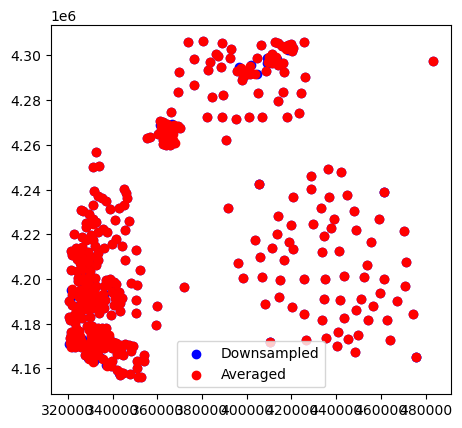

In [84]:
fig = plt.figure()
ax = fig.add_subplot(111)
downsampled_gdf.plot(ax=ax, color='blue', label='Downsampled')
averaged_gdf.plot(ax=ax, color='red', label='Averaged')
plt.legend()
plt.show()


In [89]:
md = MTData()
md.add_station(averaged_gdf["mt_obj"].to_list())

In [91]:
new_periods = np.logspace(np.log10(1./500), np.log10(8000), 23)
md_interp = md.interpolate(new_periods, bounds_error=False, inplace=False)

26:03:25T12:50:45 | WARNING | line:890 |mtpy.core.mt | interpolate | Station mina_avg002: Interpolated Z values are all NaN, consider an alternative interpolation method. See scipy.interpolate.interp1d for more information.
26:03:25T12:51:16 | WARNING | line:890 |mtpy.core.mt | interpolate | Station lv13: Interpolated Z values are all NaN, consider an alternative interpolation method. See scipy.interpolate.interp1d for more information.
26:03:25T12:51:16 | WARNING | line:890 |mtpy.core.mt | interpolate | Station lv10: Interpolated Z values are all NaN, consider an alternative interpolation method. See scipy.interpolate.interp1d for more information.
26:03:25T12:51:18 | WARNING | line:890 |mtpy.core.mt | interpolate | Station lv09: Interpolated Z values are all NaN, consider an alternative interpolation method. See scipy.interpolate.interp1d for more information.
26:03:25T12:51:19 | WARNING | line:795 |mtpy.core.transfer_function.base | interpolate | Some target periods outside source r

In [95]:
md_interp.utm_crs = 32611
md_interp.compute_relative_locations()


In [98]:
modem_data = md_interp.to_modem(r"c:\Users\jpeacock\OneDrive - DOI\Geothermal\GreatBasin\modem_inv\mina_inv_01\mina_modem_data.dat")

26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xx 6975 times. Setting error as z_xx x 0.03.
26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_xy 6975 times. Setting error as z_xy x 0.03.
26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yx 6975 times. Setting error as z_yx x 0.03.
26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in z_yy 6975 times. Setting error as z_yy x 0.03.
26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 in t_zx 7242 times. Setting error as t_zx x 0.02.
26:03:25T12:59:06 | WARNING | line:515 |mtpy.modeling.modem.data | _check_for_errors_of_zero | Found errors with values of 0 

In [96]:

md_interp.compute_model_errors(
    z_error_type="eigen",
    z_error_value=0.03,
    t_error_type="absolute",
    t_error_value=0.02,
)

IndexError: tuple index out of range

In [100]:
md_interp.center_point

MT Location: 
--------------------
  Latitude (deg):   38.222568
  Longitude (deg):  -118.120823
  Elevation (m):    0.0000
  Datum crs:        EPSG:4326

  Easting (m):      401891.396
  Northing (m):     4231103.678
  UTM crs:          EPSG:32611

  Model Easting (m):      401891.396
  Model Northing (m):     4231103.678
  Model Elevation (m):    0.000
  Profile Offset (m):     0.000

In [ ]:
""